In [2]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

In [3]:
x_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

In [4]:
print(x_train[: , 0])
print(x_train[: , 1])

[0.5 1.  1.5 3.  2.  1. ]
[1.5 1.  0.5 0.5 2.  2.5]


In [5]:
# Plotting data

def plot_data(x,y,ax):
  pos = (y==1).flatten()
  neg = (y==0).flatten()

  ax.scatter(x[pos, 0], x[pos, 1], label = 'y=1', marker='x', c='r')
  ax.scatter(x[neg, 0], x[neg, 1], label = 'y=0', marker='o', c='b')
  ax.axis([0,4,0,4])
  ax.set_title("Dataset Distribution")
  ax.legend()
  ax.set_xlabel("$x_0$")
  ax.set_ylabel("$x_1$")

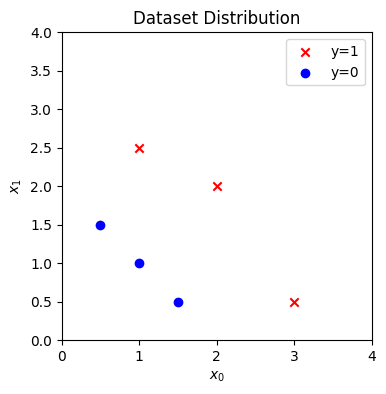

In [6]:
fig, ax = plt.subplots(1,1, figsize=(4,4))
plot_data(x_train, y_train , ax)

plt.show()

In [8]:
# Logistic Gradient Descent

def logistic_gradient_descent(x,y,w,b):

  m,n = x.shape
  dj_dw = np.zeros(n)
  dj_db = 0

  for i in range(m):
    z = np.dot(w, x[i]) + b
    f_wb_i = 1 / (1 + np.exp(-z))

    error_i = f_wb_i - y[i]
    dj_dw_i = error_i * x[i]

    dj_dw += dj_dw_i
    dj_db = dj_db + error_i

  dj_dw = (1/m) * dj_dw
  dj_db = (1/m) * dj_db

  return dj_dw, dj_db

In [9]:
w = np.array([1,1])
b= 2
dj_dw , dj_db = logistic_gradient_descent(x_train, y_train, w, b)
print(dj_dw)
print(dj_db)

[0.48746926 0.48814762]
0.48923807858754975


In [10]:
w = np.array([2, 3])
b= 1
dj_dw , dj_db = logistic_gradient_descent(x_train, y_train, w, b)
print(dj_dw)
print(dj_db)

[0.49833339 0.49883943]
0.49861806546328574


In [11]:
def sigmoid(z):
  g = 1 / (1 + np.exp(-z))
  return g

In [13]:
def logisitc_cost(x, y, w, b):
  m,n = x.shape
  j_wb = 0
  for i in range(m):
    z_i = np.dot(w, x[i]) + b
    f_wb_i = sigmoid(z_i)
    j_wb_i = -y[i] * np.log(f_wb_i) - (1 - y[i]) * (1 - f_wb_i)
    j_wb += j_wb_i

  j_wb = j_wb / m
  return j_wb

In [25]:
from typing import Iterator
def gradient_descent(x,y,w_in,b_in,alpha,iters, logistic_gradient_fun, cost_fun):
  cost_history = []
  w = copy.deepcopy(w_in)
  b = b_in

  for i in range(iters):

    dj_dw, dj_db = logistic_gradient_fun(x,y,w,b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i < 1000:
      cost_history.append(cost_fun(x,y,w,b))

    if i % math.ceil(iters / 10 ) == 0:
      print(f"Iterations: {i:4d}, Cost: {cost_history[-1]}")

  return w , b, cost_history

In [26]:
w = np.zeros_like(x_train[0])
b = 1
alpha = 0.1
iters = 10000

w_f , b_f, cost_hist = gradient_descent(x_train , y_train , w, b, alpha , iters, logistic_gradient_descent, logisitc_cost)
print(f"w final: {w_f} , b final : {b_f}")


Iterations:    0, Cost: 0.02659073249969911
Iterations: 1000, Cost: -0.34114552966257267
Iterations: 2000, Cost: -0.34114552966257267
Iterations: 3000, Cost: -0.34114552966257267
Iterations: 4000, Cost: -0.34114552966257267
Iterations: 5000, Cost: -0.34114552966257267
Iterations: 6000, Cost: -0.34114552966257267
Iterations: 7000, Cost: -0.34114552966257267
Iterations: 8000, Cost: -0.34114552966257267
Iterations: 9000, Cost: -0.34114552966257267
w final: [5.27194991 5.06885616] , b final : -14.196755795245483
